# 📊 ARIMA Time Series Forecasting - BTC Price

In this project, we will:
- Fetch BTC-USD data from Yahoo Finance
- Check stationarity using ADF test
- Apply differencing
- Use ACF & PACF to find p, d, q
- Build ARIMA model
- Forecast future prices

## ⚙️ Setup & Import Libraries

In this step, we install and import all required libraries for time series forecasting.

- **yfinance** → to fetch Bitcoin data  
- **pandas** → for data manipulation  
- **matplotlib** → for visualization  
- **statsmodels** → for ARIMA model, ADF test, ACF & PACF plots  

In [41]:
# Install required libraries
!pip install yfinance statsmodels matplotlib pandas

# Import libraries
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Time series tools
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Tirupati\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


## 📥 Step 1: Fetch BTC Data

We will download Bitcoin historical price data.

In [2]:
data = yf.download("BTC-USD", start="2021-03-26", end="2026-03-26")

ts = data['Close']

ts.head()

C:\Users\Tirupati\AppData\Local\Temp\ipykernel_11632\295162678.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("BTC-USD", start="2021-03-26", end="2026-03-26")
[*********************100%***********************]  1 of 1 completed


Ticker,BTC-USD
Date,
2021-03-26,55137.312500
2021-03-27,55973.511719
2021-03-28,55950.746094
2021-03-29,57750.199219
2021-03-30,58917.691406


## 📈 Step 2: Visualize Data

Check trend and pattern

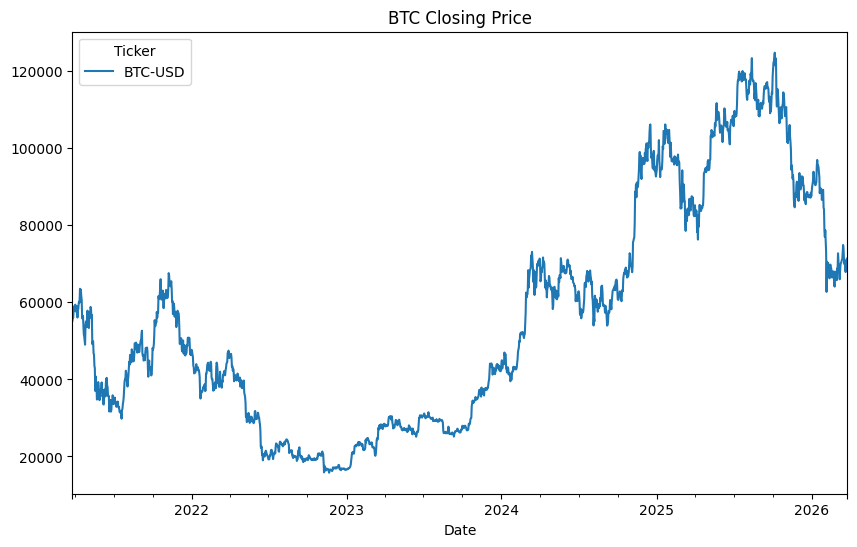

In [9]:
ts.plot(figsize=(10,6), title="BTC Closing Price")
plt.show()

## 🔍 Step 3: Check Stationarity (ADF Test)

- H0: Data is non-stationary
- If p-value < 0.05 → stationary

In [4]:
result = adfuller(ts)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: nan
p-value: nan


## 🔄 Step 4: Apply Differencing

Make data stationary

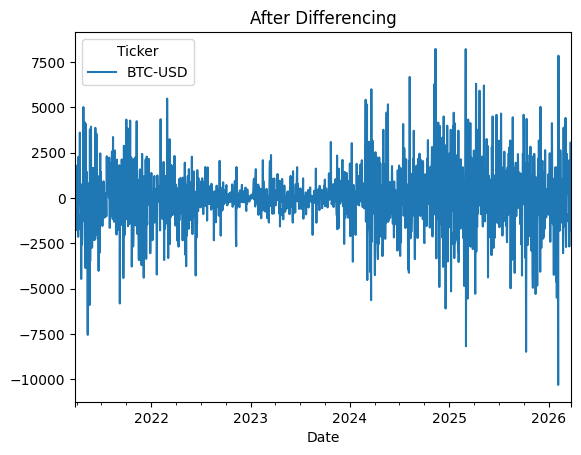

In [5]:
ts_diff = ts.diff().dropna()

ts_diff.plot(title="After Differencing")
plt.show()

In [6]:
result = adfuller(ts_diff)

print("p-value after differencing:", result[1])

p-value after differencing: 3.658990275506408e-12


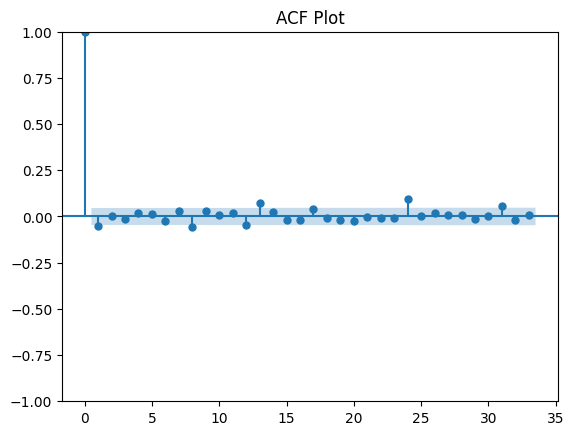

In [15]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(ts_diff)
plt.title("ACF Plot")
plt.show()

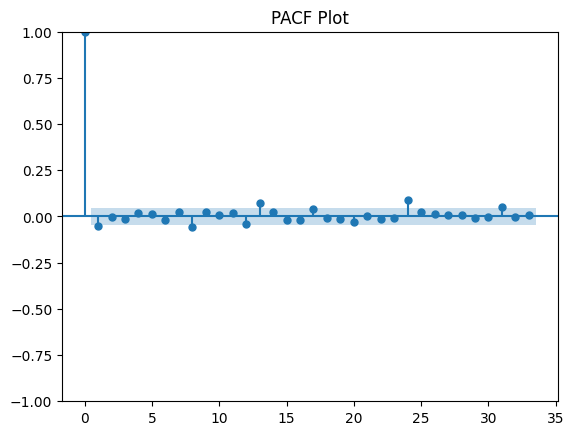

In [16]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(ts_diff)
plt.title("PACF Plot")
plt.show()

In [25]:
# Train-Test Split
train_size = int(len(ts) * 0.8)

train = ts[:train_size]
test = ts[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 1460
Test size: 366


In [28]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Manual ARIMA (1,1,0)
model_manual = ARIMA(train, order=(1,1,1))
model_manual_fit = model_manual.fit()

pred_manual = model_manual_fit.forecast(steps=len(test))

rmse_manual = np.sqrt(mean_squared_error(test, pred_manual))

print("Manual ARIMA RMSE:", rmse_manual)

Manual ARIMA RMSE: 19154.69674089747


C:\Users\Tirupati\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Tirupati\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Tirupati\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [29]:
!pip install pmdarima

from pmdarima import auto_arima

# Auto ARIMA
auto_model = auto_arima(train,
                        seasonal=False,
                        trace=True,
                        suppress_warnings=True)

print(auto_model.summary())

# Forecast
pred_auto = auto_model.predict(n_periods=len(test))

rmse_auto = np.sqrt(mean_squared_error(test, pred_auto))

print("Auto ARIMA RMSE:", rmse_auto)

Performing stepwise search to minimize aic



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Tirupati\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=25478.300, Time=2.05 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=25486.650, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=25485.683, Time=0.09 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=25485.687, Time=0.11 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=25484.969, Time=0.02 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=25489.665, Time=0.16 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=25489.683, Time=0.16 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=25479.524, Time=1.83 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=25487.041, Time=1.62 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=25487.684, Time=0.12 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=25490.486, Time=0.61 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=25490.731, Time=0.48 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=25485.695, Time=2.21 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=25476.728, Time=1.35 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=25488.032, Time=0.10

In [30]:
# Future prediction (next 30 days)
n_days = 30

future_forecast = auto_model.predict(n_periods=n_days)

print(future_forecast)

2025-03-25    87729.089698
2025-03-26    87852.216970
2025-03-27    87707.507933
2025-03-28    87496.568253
2025-03-29    87502.869376
2025-03-30    87711.034332
2025-03-31    87836.939154
2025-04-01    87715.295657
2025-04-02    87516.294133
2025-04-03    87507.840390
2025-04-04    87695.093857
2025-04-05    87822.019356
2025-04-06    87721.263399
2025-04-07    87534.519382
2025-04-08    87513.621374
2025-04-09    87681.119475
2025-04-10    87807.562342
2025-04-11    87725.621621
2025-04-12    87551.276054
2025-04-13    87520.028950
2025-04-14    87668.963873
2025-04-15    87793.652194
2025-04-16    87728.566223
2025-04-17    87566.606994
2025-04-18    87526.900674
2025-04-19    87658.482573
2025-04-20    87780.354520
2025-04-21    87730.278650
2025-04-22    87580.563760
2025-04-23    87534.093617
Freq: D, dtype: float64


In [33]:
# Create future dates
last_date = ts.index[-1]

future_dates = pd.date_range(start=last_date, periods=n_days+1, freq='D')[1:]

# Convert to Series
future_series = pd.Series(future_forecast)

print(future_series.head())

2025-03-25    87729.089698
2025-03-26    87852.216970
2025-03-27    87707.507933
2025-03-28    87496.568253
2025-03-29    87502.869376
Freq: D, dtype: float64


<Figure size 1200x600 with 0 Axes>

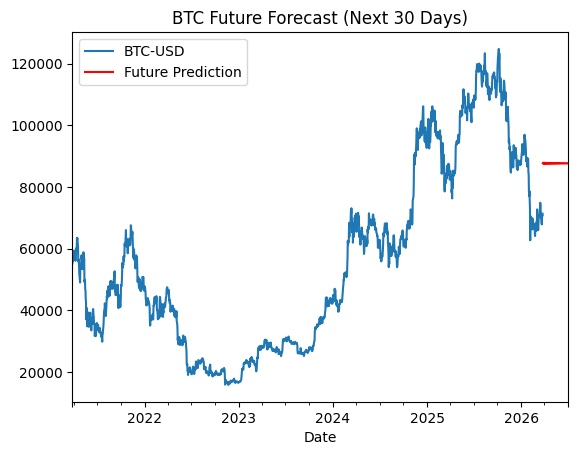

In [39]:
plt.figure(figsize=(12,6))

# original data
ts.plot(label="Original")

# future prediction
future_series.plot(label="Future Prediction", color='red')

plt.legend()
plt.title("BTC Future Forecast (Next 30 Days)")
plt.show()

In [35]:
# correct mapping
future_series.index = pd.date_range(
    start=ts.index[-1] + pd.Timedelta(days=1),
    periods=len(future_series),
    freq='D'
)

print(future_series.head())

2026-03-26    87729.089698
2026-03-27    87852.216970
2026-03-28    87707.507933
2026-03-29    87496.568253
2026-03-30    87502.869376
Freq: D, dtype: float64


<Figure size 1200x600 with 0 Axes>

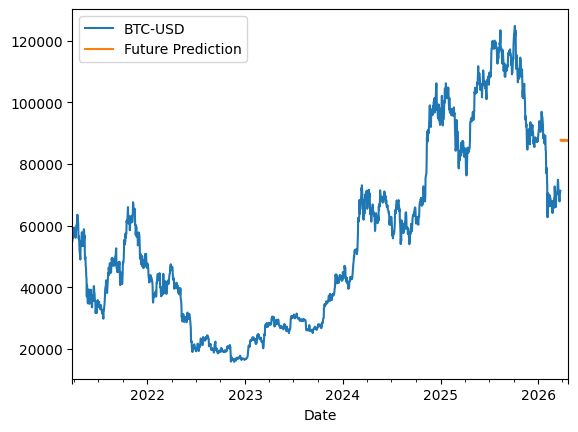

In [36]:
plt.figure(figsize=(12,6))

ts.plot(label="Original")
future_series.plot(label="Future Prediction")

plt.legend()
plt.show()

<Figure size 1200x600 with 0 Axes>

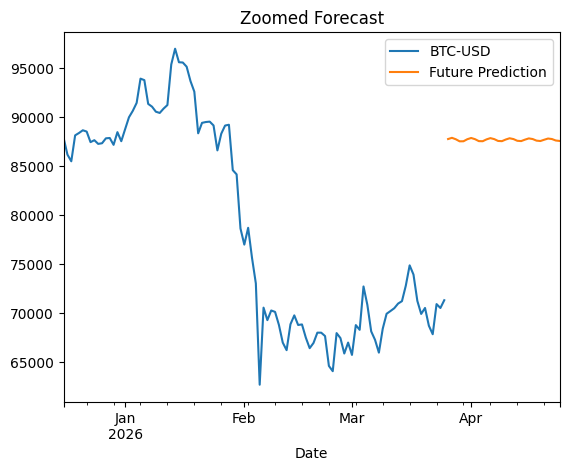

In [37]:
plt.figure(figsize=(12,6))

# last 100 days only
ts[-100:].plot(label="Original")
future_series.plot(label="Future Prediction")

plt.legend()
plt.title("Zoomed Forecast")
plt.show()